# Load & Clean CL Fed Appellate data

# Import libraries

In [1]:
import numpy as np
import pandas as pd

from cl_utils import *
from clean_utils import *

from clean_utils import do_cleaning

# Load the CL scotus data, to prepare for joining with scotus scraped data

In [2]:
courts = ["scotus", "cadc", "ca1", "ca2", "ca3", "ca4", "ca5", "ca6", "ca7", "ca8", "ca9", "ca10", "ca11"]
sample_size = 26000

In [3]:
df = pd.DataFrame()
for court in courts:
    court_df = load_courts_to_df([court], f"cl_{court}")
    court_df = court_df[['docket_id', 'court_id', 'docket_number_raw']].drop_duplicates().reset_index(drop=True)
    df = pd.concat([df, court_df], ignore_index=True)
df = df.reset_index(drop=True)
df = df.sample(sample_size, random_state=42).reset_index(drop=True)
df.to_csv(f"predictions/all_courts_sample.csv", index=False)
len(df)

26000

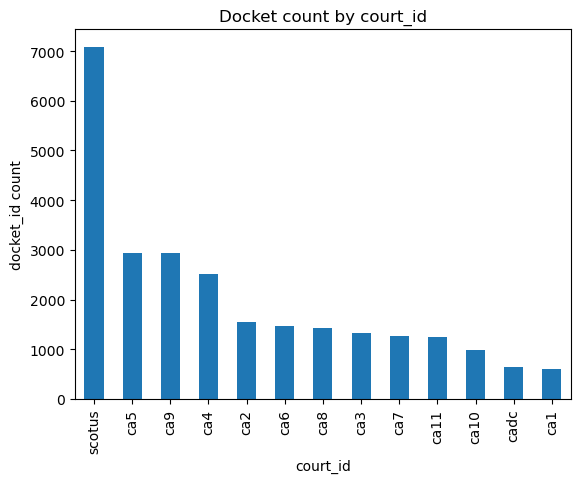

In [9]:
df["court_id"].value_counts().plot(kind='bar')
import matplotlib.pyplot as plt
plt.xlabel("court_id")
plt.ylabel("docket_id count")
plt.title("Docket count by court_id")
plt.show()

In [5]:
%%time

cleaned_df = do_cleaning(df)

cleaned_df.to_csv(f"predictions/all_courts_clean.csv", index=False)
cleaned_df.head()

***Processing 100 records***
***Processing 8 records with LLM***
Processing court: fed_appellate with 8 records
---Processing 8 records with gpt-4o-mini---


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:Processed batch 0


---0 remaining---
---Processing 8 records with gpt-4.1-mini---


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:Processed batch 0


---0 remaining---
---Processing 1 records with gpt-4o---


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:Processed batch 0


---0 remaining---
---Processing 1 records with gpt-4.1---


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:Processed batch 0


---0 remaining---
CPU times: user 171 ms, sys: 19.7 ms, total: 190 ms
Wall time: 10.3 s


,docket_id,court_id,docket_number_raw,docket_number,cleaned_with
0,85275,ca9,85-3054,85-3054,regex
1,66735897,ca9,21-16380,21-16380,regex
2,914936,ca4,06-4890,06-4890,regex
3,1935303,ca4,95-7847,95-7847,regex
4,1458326,ca6,81-1318,81-1318,regex


In [6]:
len(cleaned_df)

100

In [7]:
cleaned_df["cleaned_with"].value_counts()

cleaned_with
regex    92
mini      7
full      1
Name: count, dtype: int64

In [8]:
raw_output_df = pd.read_json(f"predictions/raw_output.jsonl", lines=True)

raw_output_df.head()

,model,input_tokens,cached_tokens,output_tokens,raw_results,parsed_results
0,gpt-4o-mini-2024-07-18,2640,0,170,"{""docket_numbers"":[{""unique_id"":""64202599"",""cl...","{'docket_numbers': [{'unique_id': '64202599', ..."
1,gpt-4.1-mini-2025-04-14,2640,0,179,"{""docket_numbers"":[{""unique_id"":""64202599"",""cl...","{'docket_numbers': [{'unique_id': '64202599', ..."
2,gpt-4o-2024-08-06,2503,0,31,"{""docket_numbers"":[{""unique_id"":""64202599"",""cl...","{'docket_numbers': [{'unique_id': '64202599', ..."
3,gpt-4.1-2025-04-14,2503,0,31,"{""docket_numbers"":[{""unique_id"":""64202599"",""cl...","{'docket_numbers': [{'unique_id': '64202599', ..."


In [9]:
raw_output_df["model"].unique()

array(['gpt-4o-mini-2024-07-18', 'gpt-4.1-mini-2025-04-14',
       'gpt-4o-2024-08-06', 'gpt-4.1-2025-04-14'], dtype=object)

In [10]:
model = 'gpt-4o-mini-2024-07-18'
print(model)
print("Cached Tokens", raw_output_df[raw_output_df["model"] == model]["cached_tokens"].sum())
print("Input Tokens", raw_output_df[raw_output_df["model"] == model]["input_tokens"].sum())
print("Output Tokens", raw_output_df[raw_output_df["model"] == model]["output_tokens"].sum())

gpt-4o-mini-2024-07-18
Cached Tokens 0
Input Tokens 2640
Output Tokens 170


In [11]:
model = 'gpt-4.1-mini-2025-04-14'
print(model)
print("Cached Tokens", raw_output_df[raw_output_df["model"] == model]["cached_tokens"].sum())
print("Input Tokens", raw_output_df[raw_output_df["model"] == model]["input_tokens"].sum())
print("Output Tokens", raw_output_df[raw_output_df["model"] == model]["output_tokens"].sum())

gpt-4.1-mini-2025-04-14
Cached Tokens 0
Input Tokens 2640
Output Tokens 179


In [12]:
model = 'gpt-4o-2024-08-06'
print(model)
print("Cached Tokens", raw_output_df[raw_output_df["model"] == model]["cached_tokens"].sum())
print("Input Tokens", raw_output_df[raw_output_df["model"] == model]["input_tokens"].sum())
print("Output Tokens", raw_output_df[raw_output_df["model"] == model]["output_tokens"].sum())

gpt-4o-2024-08-06
Cached Tokens 0
Input Tokens 2503
Output Tokens 31


In [13]:
model = 'gpt-4.1-2025-04-14'
print(model)
print("Cached Tokens", raw_output_df[raw_output_df["model"] == model]["cached_tokens"].sum())
print("Input Tokens", raw_output_df[raw_output_df["model"] == model]["input_tokens"].sum())
print("Output Tokens", raw_output_df[raw_output_df["model"] == model]["output_tokens"].sum())

gpt-4.1-2025-04-14
Cached Tokens 0
Input Tokens 2503
Output Tokens 31
